In [1]:
import pandas as pd
import numpy as np

### Data Loading and Exploration

In [2]:
def load_arff_to_dataframe(file_path):
    """
    Load ARFF file and convert it to a pandas DataFrame
    """
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
        
        # Find attribute definitions and data section
        attributes = []
        data_start_idx = 0
        
        for i, line in enumerate(lines):
            line = line.strip()
            if line.startswith('@attribute'):
                # Extract attribute name (remove quotes if present)
                parts = line.split()
                attr_name = parts[1].replace("'", "").replace('"', '')
                attributes.append(attr_name)
            elif line.startswith('@data'):
                data_start_idx = i + 1
                break
        
        # Extract data rows
        data_rows = []
        for i in range(data_start_idx, len(lines)):
            line = lines[i].strip()
            if line and not line.startswith('%'):  # Skip empty lines and comments
                # Split by comma and clean each value
                row = [val.strip() if val.strip() != '?' else np.nan for val in line.split(',')]
                data_rows.append(row)
        
        # Ensure consistent row lengths - trim to match number of attributes
        for i, row in enumerate(data_rows):
            if len(row) > len(attributes):
                data_rows[i] = row[:len(attributes)]  # Trim extra columns
            elif len(row) < len(attributes):
                data_rows[i].extend([np.nan] * (len(attributes) - len(row)))  # Pad with NaN
        
        # Create DataFrame
        df = pd.DataFrame(data_rows, columns=attributes)
        
        # Convert numeric columns to appropriate types
        numeric_cols = ['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc', 'rbcc']
        for col in numeric_cols:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors='coerce')
        
        return df
        
    except Exception as e:
        print(f"Error loading ARFF file: {e}")
        return None



In [3]:
# Load the chronic kidney disease dataset
file_path = 'chronic_kidney_disease.arff'
df = load_arff_to_dataframe(file_path)

df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1,0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4,0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2,3,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4,0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2,0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    object 
 3   al      354 non-null    object 
 4   su      351 non-null    object 
 5   rbc     248 non-null    object 
 6   pc      335 non-null    object 
 7   pcc     396 non-null    object 
 8   ba      396 non-null    object 
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    object 
 19  dm      398 non-null    object 
 20  cad     398 non-null    object 
 21  appet   399 non-null    object 
 22  pe

In [5]:
print(f"\nMissing values:")
df.isnull().sum()


Missing values:


age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wbcc     106
rbcc     131
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64

Separate numerical and categorical features

In [6]:
# check all datatypes of dataframe 
df.dtypes

age      float64
bp       float64
sg        object
al        object
su        object
rbc       object
pc        object
pcc       object
ba        object
bgr      float64
bu       float64
sc       float64
sod      float64
pot      float64
hemo     float64
pcv      float64
wbcc     float64
rbcc     float64
htn       object
dm        object
cad       object
appet     object
pe        object
ane       object
class     object
dtype: object

In [7]:
numertic_cols = df.select_dtypes(include=['float64', 'int64']).columns
catergorical_cols = df.select_dtypes(include=['object']).columns

print(f"numertic_cols: {numertic_cols}")
print(f"catergorical_cols: {catergorical_cols}")

numertic_cols: Index(['age', 'bp', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wbcc',
       'rbcc'],
      dtype='object')
catergorical_cols: Index(['sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet',
       'pe', 'ane', 'class'],
      dtype='object')


### Preprocess

**Label encoding (categorical features)**

- which converts categorical text/string values into numerical values that machine learning algorithms can process.


In [8]:
from sklearn.preprocessing import LabelEncoder

In [9]:
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1,0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4,0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2,3,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4,0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2,0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [10]:

# Encode categorical columns
df_processed = df.copy()
for col in catergorical_cols:
    
    if col in df_processed.columns:
        # filling missing values with mode
        col_mode = df_processed[col].mode()[0]
        df_processed[col] = df_processed[col].fillna(col_mode)

        # label encoding
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col])
        

        
df_processed

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,3,1,0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,2,0,0,1,0,0
1,7.0,50.0,3,4,0,1,1,0,0,NaN,...,38.0,6000.0,NaN,0,1,0,0,1,0,0
2,62.0,80.0,1,2,3,1,1,0,0,423.0,...,31.0,7500.0,NaN,0,2,0,2,1,1,0
3,48.0,70.0,0,4,0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,1,0,2,2,1,0
4,51.0,80.0,1,2,0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,3,0,0,1,1,0,0,140.0,...,47.0,6700.0,4.9,0,1,0,0,1,0,2
396,42.0,70.0,4,0,0,1,1,0,0,75.0,...,54.0,7800.0,6.2,0,1,0,0,1,0,2
397,12.0,80.0,3,0,0,1,1,0,0,100.0,...,49.0,6600.0,5.4,0,1,0,0,1,0,2
398,17.0,60.0,4,0,0,1,1,0,0,114.0,...,51.0,7200.0,5.9,0,1,0,0,1,0,2


**Note**

Using `median` is more accurate that the mean in this case

- Robust to outliers: Medical data often contains extreme values
- Preserves distribution: Doesn't shift the data as much as mean
- Appropriate for skewed data: Medical measurements are often not normally distributed

In [11]:
# fill missing numerical features
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

numeric_features = df_processed[numertic_cols]
df_processed[numertic_cols] = imputer.fit_transform(numeric_features)

df_processed

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,3,1,0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,2,0,0,1,0,0
1,7.0,50.0,3,4,0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,1,0,0,1,0,0
2,62.0,80.0,1,2,3,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,2,0,2,1,1,0
3,48.0,70.0,0,4,0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,1,0,2,2,1,0
4,51.0,80.0,1,2,0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,1,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,3,0,0,1,1,0,0,140.0,...,47.0,6700.0,4.9,0,1,0,0,1,0,2
396,42.0,70.0,4,0,0,1,1,0,0,75.0,...,54.0,7800.0,6.2,0,1,0,0,1,0,2
397,12.0,80.0,3,0,0,1,1,0,0,100.0,...,49.0,6600.0,5.4,0,1,0,0,1,0,2
398,17.0,60.0,4,0,0,1,1,0,0,114.0,...,51.0,7200.0,5.9,0,1,0,0,1,0,2


In [12]:
df_processed.isnull().sum()

age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64

### Data Cleaning

Remove classes with insufficient samples for cross-validation

In [13]:
# Check class distribution and clean data
print("Original class distribution:")
print(df_processed['class'].value_counts())

# Remove rare classes (less than 5 samples for 5-fold CV)
class_counts = df_processed['class'].value_counts()
min_samples = 5 

print(f"\nRemoving classes with fewer than {min_samples} samples...")
valid_classes = class_counts[class_counts >= min_samples].index

# Filter data
df_cleaned = df_processed[df_processed['class'].isin(valid_classes)].copy()

print(f"Classes removed: {set(class_counts.index) - set(valid_classes)}")
print(f"Final class distribution:")
print(df_cleaned['class'].value_counts())
print(f"Final dataset shape: {df_cleaned.shape}")

Original class distribution:
class
0    250
2    149
1      1
Name: count, dtype: int64

Removing classes with fewer than 5 samples...
Classes removed: {1}
Final class distribution:
class
0    250
2    149
Name: count, dtype: int64
Final dataset shape: (399, 25)


### Split & Scale

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [15]:
y = df_cleaned['class']
x = df_cleaned.drop(columns=['class'])

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2, 
    stratify=y,  
    random_state=42
)

print(f"Training set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")
print(f"Training class distribution:")
print(pd.Series(y_train).value_counts())

Training set shape: (319, 24)
Test set shape: (80, 24)
Training class distribution:
class
0    200
2    119
Name: count, dtype: int64


### Tuning & Training

In [16]:
# Hyperparameter Tuning (Fixed)
from sklearn.neighbors import KNeighborsClassifier

# Check class distribution first
print("Class distribution in training set:")
print(pd.Series(y_train).value_counts())

# Now we can safely use 5-fold CV since all classes have ≥5 samples
cv_folds = 5
print(f"Using {cv_folds}-fold cross-validation")

cv_score = []

for k in range(1, 21):  # Test K from 1 to 20
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95, random_state=42)),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    scores = cross_val_score(pipeline, x_train, y_train, cv=cv_folds, scoring='accuracy')
    cv_score.append(scores.mean())
    
    # Print progress for first 10 and every 5th
    if k <= 10 or k % 5 == 0:
        print(f"K={k}: CV Accuracy = {scores.mean():.4f} (±{scores.std():.4f})")

print(f"\nCV Scores: {cv_score}")
best_score = max(cv_score)
best_k = cv_score.index(best_score) + 1

print(f"\nBest K: {best_k}")
print(f"Best CV Accuracy: {best_score:.4f}")

Class distribution in training set:
class
0    200
2    119
Name: count, dtype: int64
Using 5-fold cross-validation
K=1: CV Accuracy = 0.9875 (±0.0117)
K=2: CV Accuracy = 0.9938 (±0.0077)
K=3: CV Accuracy = 0.9750 (±0.0125)
K=4: CV Accuracy = 0.9812 (±0.0117)
K=5: CV Accuracy = 0.9687 (±0.0171)
K=6: CV Accuracy = 0.9750 (±0.0159)
K=7: CV Accuracy = 0.9624 (±0.0159)
K=8: CV Accuracy = 0.9655 (±0.0182)
K=9: CV Accuracy = 0.9624 (±0.0234)
K=10: CV Accuracy = 0.9718 (±0.0207)
K=15: CV Accuracy = 0.9467 (±0.0212)
K=20: CV Accuracy = 0.9310 (±0.0275)

CV Scores: [np.float64(0.9875), np.float64(0.99375), np.float64(0.9749503968253969), np.float64(0.9812003968253968), np.float64(0.9686507936507937), np.float64(0.9749503968253969), np.float64(0.9624007936507937), np.float64(0.9655257936507937), np.float64(0.9624007936507937), np.float64(0.9717757936507937), np.float64(0.9624007936507937), np.float64(0.9655257936507937), np.float64(0.9561507936507937), np.float64(0.9561507936507937), np.float64(

Visualize K vs Accuracy

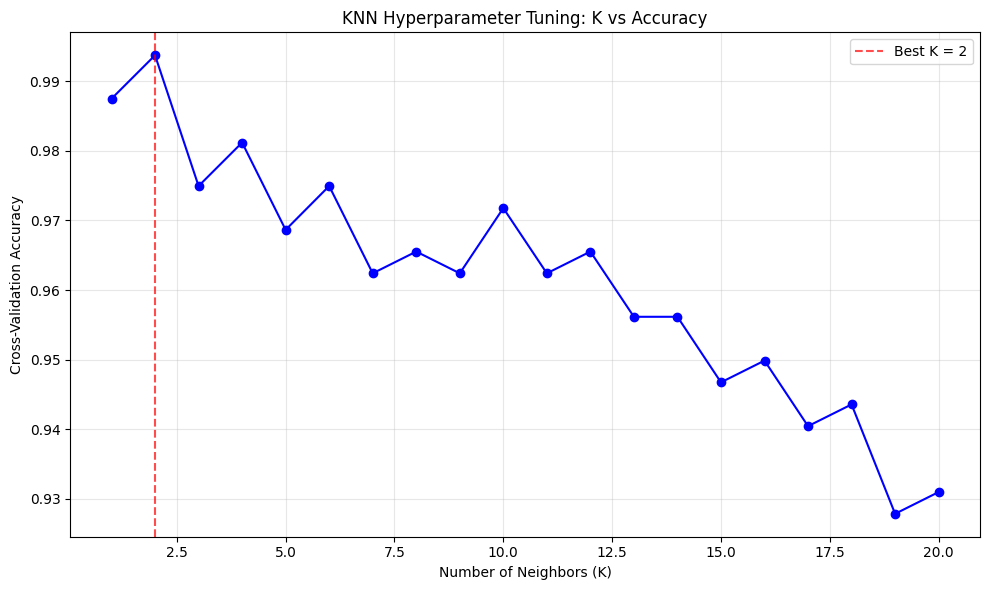

In [17]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(range(1, 21), cv_score, 'bo-', markersize=6)
plt.axvline(x=best_k, color='r', linestyle='--', alpha=0.7, label=f'Best K = {best_k}')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN Hyperparameter Tuning: K vs Accuracy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Evaluate model

In [18]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the final model with best K
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])

final_pipeline.fit(x_train, y_train)



,steps,"[('scaler', ...), ('pca', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,0.95
,copy,True
,whiten,False
,svd_solver,'auto'


In [19]:
# Make predictions
y_pred = final_pipeline.predict(x_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Final Model Performance (K={best_k}):")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Cross-Validation Accuracy: {best_score:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

Final Model Performance (K=2):
Test Accuracy: 0.9750
Cross-Validation Accuracy: 0.9938

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        50
           2       0.97      0.97      0.97        30

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80


Confusion Matrix:
[[49  1]
 [ 1 29]]


In [20]:

# Report PCA dimensionality used
pca_step = final_pipeline.named_steps['pca']
print(f"PCA retained {pca_step.n_components_} components to preserve 95% variance.")

PCA retained 20 components to preserve 95% variance.
